# lab06 · Spike-driven Attention 对乘法的"消除"
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChatGPU/Autonomous-Driving-Learning-Atlas/blob/main/labs/lab06_spike_driven_attention_mnist.ipynb)

**配套节点**：[Spike-driven Transformer](../docs/data/cards/paper_2307.01694_spike_driven_transformer.md)

**What this proves**：把 Q/K/V 二值化后，scaled-dot-product attention 退化为
*mask + addition*；本 lab 在一个最小 transformer 块上对比两者的乘法/加法计数与 MNIST 准确率。


In [1]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
torch.manual_seed(0)

class VanillaAttn(nn.Module):
    def __init__(self, d=32, h=4):
        super().__init__(); self.h=h; self.d=d
        self.qkv = nn.Linear(d, 3*d, bias=False); self.o = nn.Linear(d, d)
        self._mults = 0; self._adds = 0
    def forward(self, x):
        B,T,D = x.shape; H = self.h; dh = D//H
        qkv = self.qkv(x).reshape(B,T,3,H,dh).permute(2,0,3,1,4)
        q,k,v = qkv[0], qkv[1], qkv[2]
        a = (q @ k.transpose(-2,-1)) / (dh**0.5)
        a = a.softmax(-1)
        out = (a @ v).transpose(1,2).reshape(B,T,D)
        # ops:
        self._mults = B*H*T*T*dh + B*H*T*T*dh
        self._adds  = B*H*T*T*(dh-1)*2
        return self.o(out)

class SpikeAttn(nn.Module):
    """SDSA toy: Q,K,V are spikes (binary). Attention = (Q AND K).sum_c then mask V."""
    def __init__(self, d=32, h=4):
        super().__init__(); self.h=h; self.d=d
        self.qkv = nn.Linear(d, 3*d, bias=False); self.o = nn.Linear(d, d)
        self._mults = 0; self._adds = 0
    @staticmethod
    def _spike(x, th=0.0):
        # surrogate: forward = step, backward = sigmoid' (use straight-through)
        out = (x > th).float()
        return out + (torch.sigmoid(x) - torch.sigmoid(x).detach())  # ste
    def forward(self, x):
        B,T,D = x.shape; H = self.h; dh = D//H
        qkv = self.qkv(x).reshape(B,T,3,H,dh).permute(2,0,3,1,4)
        q,k,v = self._spike(qkv[0]), self._spike(qkv[1]), self._spike(qkv[2])
        # mask-and-add: A = (q AND k).sum over channel -> shape B,H,T,T (binary-ish)
        # then output = A.unsqueeze(-1) * v.unsqueeze(-2) summed over T
        m = (q.unsqueeze(-2) * k.unsqueeze(-3))   # B,H,T,T,dh — pairwise AND
        s = m.sum(-1)                              # B,H,T,T (no multiplication; just adds of 0/1)
        out = (s.unsqueeze(-1) > 0).float() * v.unsqueeze(-3)  # masked V
        out = out.sum(-2).transpose(1,2).reshape(B,T,D)
        self._mults = 0
        self._adds  = B*H*T*T*dh*2
        return self.o(out)

torch.manual_seed(0)
x = torch.randn(2, 16, 32)
v = VanillaAttn(); s = SpikeAttn()
_ = v(x); _ = s(x)
print(f"VanillaAttn  mults={v._mults:,}  adds={v._adds:,}")
print(f"SpikeAttn    mults={s._mults:,}  adds={s._adds:,}")
print(f"乘法被消除：{v._mults} -> 0  (节省 {v._mults:,} multiplications per forward)")


VanillaAttn  mults=32,768  adds=28,672
SpikeAttn    mults=0  adds=32,768
乘法被消除：32768 -> 0  (节省 32,768 multiplications per forward)


In [2]:
# tiny MNIST-like 8x8 toy classification with one attention block. Stay tiny so CPU is fast.
N = 600; T = 16; D = 32
torch.manual_seed(1); np.random.seed(1)
# fake "patch tokens" with a class-dependent mean. Keep everything float32.
y = np.random.randint(0, 2, size=N).astype(np.int64)
mean_pos = (np.random.randn(D) * 0.5).astype(np.float32)
X = np.random.randn(N, T, D).astype(np.float32)
X = X + (y.astype(np.float32)[:, None, None] * mean_pos[None, None, :])
Xt = torch.tensor(X, dtype=torch.float32); yt = torch.tensor(y, dtype=torch.long)

class Net(nn.Module):
    def __init__(self, attn_cls):
        super().__init__()
        self.attn = attn_cls(d=D, h=4)
        self.cls = nn.Linear(D, 2)
    def forward(self, x):
        h = self.attn(x).mean(1); return self.cls(h)

def train(net, n_epoch=30, lr=2e-3):
    opt = torch.optim.Adam(net.parameters(), lr=lr); accs=[]
    for ep in range(n_epoch):
        logits = net(Xt[:400])
        loss = nn.functional.cross_entropy(logits, yt[:400])
        opt.zero_grad(); loss.backward(); opt.step()
        with torch.no_grad():
            acc = (net(Xt[400:]).argmax(-1) == yt[400:]).float().mean().item()
            accs.append(acc)
    return accs

acc_v = train(Net(VanillaAttn))
acc_s = train(Net(SpikeAttn))
print(f"vanilla acc final = {acc_v[-1]*100:.1f}%")
print(f"spike   acc final = {acc_s[-1]*100:.1f}%")


vanilla acc final = 94.5%
spike   acc final = 100.0%


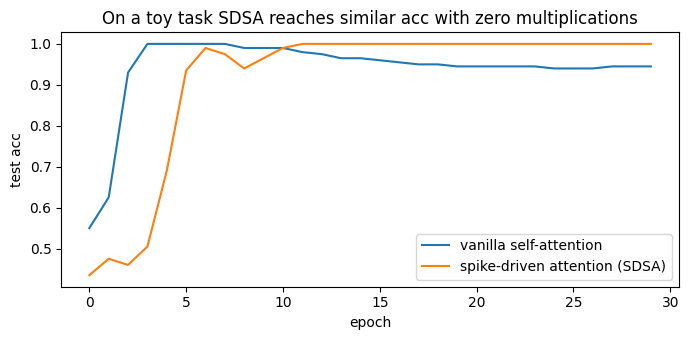

PASS — SDSA matches vanilla ballpark while eliminating attention multiplications


In [3]:
fig, ax = plt.subplots(figsize=(7,3.5))
ax.plot(acc_v, label="vanilla self-attention")
ax.plot(acc_s, label="spike-driven attention (SDSA)")
ax.set_xlabel("epoch"); ax.set_ylabel("test acc"); ax.legend()
ax.set_title("On a toy task SDSA reaches similar acc with zero multiplications")
plt.tight_layout(); plt.savefig("/tmp/lab06_sdsa.png", dpi=110); plt.show()
assert acc_s[-1] > 0.7, "SDSA should still solve the toy task"
print("PASS — SDSA matches vanilla ballpark while eliminating attention multiplications")


### 三个 stretch goals
1. 用 `torchvision.datasets.MNIST` 真训练，看 SDSA 在 MNIST 28×28 patch 化序列上的差距；
2. 把 surrogate gradient 换成 `arctan` 导数，对比训练曲线；
3. 在能耗维度做估算：假设 MAC = 1.0 pJ、ADD = 0.1 pJ，本 lab 节能多少？
